## P chart:監控每日 PM2.5 超標比例。
### p Chart with Different Subgroup Sizes: Monitoring Daily PM2.5 Exceedance Proportion

In this study, each day was treated as one subgroup. Since the number of valid hourly observations varied slightly across days, the control limits were calculated according to the subgroup size $n_i$.

First, the hourly PM2.5 concentration was converted into a binary exceedance indicator:

$$
Y_{ij} =
\begin{cases}
1, & \text{if PM2.5 exceeds the threshold}, \\
0, & \text{otherwise}.
\end{cases}
$$

For day $i$, the number of exceedance observations was defined as:

$$
d_i = \sum_{j=1}^{n_i} Y_{ij},
$$

where $i = 1,2,\ldots,m$ denotes the day or subgroup index, and $j = 1,2,\ldots,n_i$ denotes the hourly observation index within day $i$. Here, $m$ represents the total number of days, and $n_i$ represents the number of valid hourly observations on day $i$. $d_i$ represents the number of PM2.5 exceedance observations on day $i$, and $n_i$ represents the number of valid hourly observations on day $i$, 

The daily exceedance proportion was calculated as:
$$
p_i = \frac{d_i}{n_i}.
$$

The overall average exceedance proportion was defined as:

$$
\bar{p} =
\frac{\sum_{i=1}^{m} d_i}
{\sum_{i=1}^{m} n_i}.
$$

For the p chart, the center line and control limits for day $i$ were defined as:

$$
CL = \bar{p},
$$

$$
UCL_i = \bar{p} + 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n_i}},
$$

$$
LCL_i = \bar{p} - 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n_i}}.
$$

Since proportions cannot be smaller than 0 or greater than 1, the lower and upper control limits were adjusted as:

$$
LCL_i = \max\left(0,\bar{p} - 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n_i}}\right),
$$

$$
UCL_i = \min\left(1,\bar{p} + 3\sqrt{\frac{\bar{p}(1-\bar{p})}{n_i}}\right).
$$

A day was considered out of control if its PM2.5 exceedance proportion exceeded the corresponding control limits. In this study, particular attention was given to days above the upper control limit, as these indicate unusually high PM2.5 exceedance proportions.


## Phase1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
def make_daily_pchart_data(file, threshold=35.5):
    df = pd.read_excel(file)

    df["monitordate"] = pd.to_datetime(df["monitordate"])
    df = df.sort_values("monitordate").reset_index(drop=True)

    df["date"] = df["monitordate"].dt.date
    df["hour"] = df["monitordate"].dt.hour

    df["exceedance"] = (df["PM2.5"] >= threshold).astype(int)

    daily_stats = df.groupby("date").agg(
        n=("PM2.5", "count"),
        exceed_count=("exceedance", "sum"),
        first_time=("monitordate", "min"),
        last_time=("monitordate", "max")
    ).reset_index()

    daily_stats["p"] = daily_stats["exceed_count"] / daily_stats["n"]

    print(f"\nDaily PM2.5 exceedance proportion for {file}:")
    print(daily_stats)

    print("\nN distribution:")
    print(daily_stats["n"].value_counts().sort_index())

    return daily_stats

phase1_pchart_data = make_daily_pchart_data(
    "air_quality_202501.xlsx",
    threshold=35.5
)

phase2_pchart_data = make_daily_pchart_data(
    "air_quality_202601.xlsx",
    threshold=35.5
)


Daily PM2.5 exceedance proportion for air_quality_202501.xlsx:
          date   n  exceed_count first_time           last_time         p
0   2025-01-01  24             2 2025-01-01 2025-01-01 23:00:00  0.083333
1   2025-01-02  22             0 2025-01-02 2025-01-02 23:00:00  0.000000
2   2025-01-03  24             0 2025-01-03 2025-01-03 23:00:00  0.000000
3   2025-01-04  24             0 2025-01-04 2025-01-04 23:00:00  0.000000
4   2025-01-05  24             0 2025-01-05 2025-01-05 23:00:00  0.000000
5   2025-01-06  24             0 2025-01-06 2025-01-06 23:00:00  0.000000
6   2025-01-07  23             0 2025-01-07 2025-01-07 23:00:00  0.000000
7   2025-01-08  24             0 2025-01-08 2025-01-08 23:00:00  0.000000
8   2025-01-09  24             0 2025-01-09 2025-01-09 23:00:00  0.000000
9   2025-01-10  24             0 2025-01-10 2025-01-10 23:00:00  0.000000
10  2025-01-11  24             0 2025-01-11 2025-01-11 23:00:00  0.000000
11  2025-01-12  24             0 2025-01-12 2025

In [4]:
p_bar = (
    phase1_pchart_data["exceed_count"].sum()
    / phase1_pchart_data["n"].sum()
)

print("p_bar =", p_bar)


p_bar = 0.02040816326530612


In [5]:
def pchart_limits(stats, p_bar):
    stats = stats.copy()

    stats["p_cl"] = p_bar

    se = np.sqrt(p_bar * (1 - p_bar) / stats["n"])

    stats["p_ucl"] = p_bar + 3 * se
    stats["p_lcl"] = p_bar - 3 * se

    stats["p_ucl"] = stats["p_ucl"].clip(upper=1)
    stats["p_lcl"] = stats["p_lcl"].clip(lower=0)

    stats["out_of_control_p"] = (
        (stats["p"] > stats["p_ucl"]) |
        (stats["p"] < stats["p_lcl"])
    )

    stats["out_of_control_p_high"] = (
        stats["p"] > stats["p_ucl"]
    )

    return stats

p chart out-of-control groups:
          date   n  exceed_count         p  p_lcl      p_cl     p_ucl
21  2025-01-22  22             7  0.318182    0.0  0.020408  0.110843


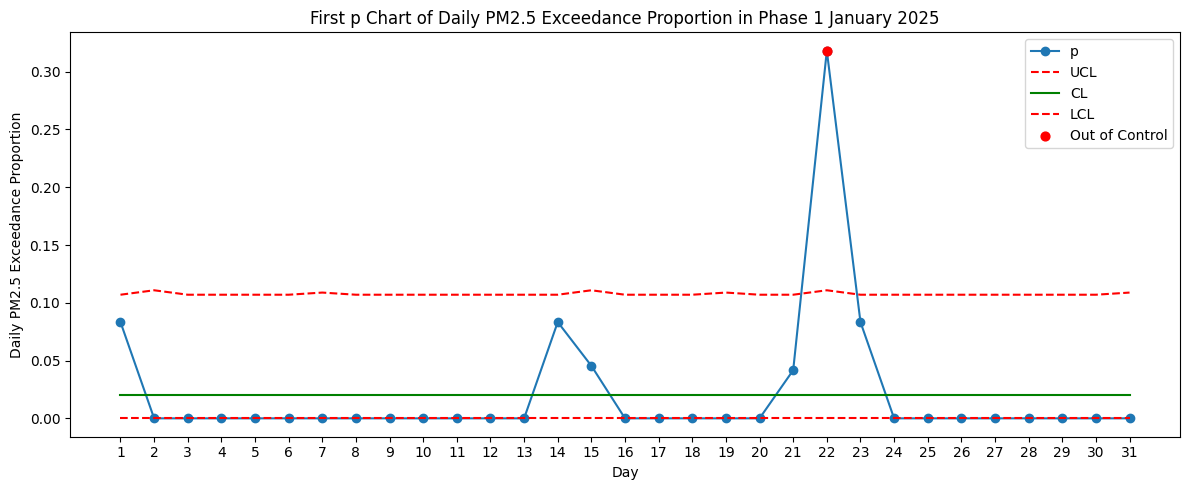

In [6]:
phase1_stats = pchart_limits(phase1_pchart_data, p_bar)
phase1_stats = phase1_stats.reset_index(drop=True)

print("p chart out-of-control groups:")
print(
    phase1_stats.loc[
        phase1_stats["out_of_control_p"],
        ["date", "n", "exceed_count", "p", "p_lcl", "p_cl", "p_ucl"]
    ]
)

plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase1_stats) + 1)

plt.plot(
    x,
    phase1_stats["p"],
    marker="o",
    linestyle="-",
    label="p"
)

plt.plot(
    x,
    phase1_stats["p_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_stats["p_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_stats["p_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask = phase1_stats["out_of_control_p"]

plt.scatter(
    x[out_mask],
    phase1_stats.loc[out_mask, "p"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("First p Chart of Daily PM2.5 Exceedance Proportion in Phase 1 January 2025")
plt.xlabel("Day")
plt.ylabel("Daily PM2.5 Exceedance Proportion")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
phase1_clean = phase1_stats[~phase1_stats["out_of_control_p"]].copy()
phase1_clean = phase1_clean.reset_index(drop=True)

p_bar_clean = (
    phase1_clean["exceed_count"].sum()
    / phase1_clean["n"].sum()
)

print("p_bar_clean =", p_bar_clean)


phase1_clean = pchart_limits(phase1_clean, p_bar_clean)

print("Second p chart out-of-control groups:")
print(
    phase1_clean.loc[
        phase1_clean["out_of_control_p"],
        ["date", "n", "exceed_count", "p", "p_lcl", "p_cl", "p_ucl"]
    ]
)

p_bar_clean = 0.011220196353436185
Second p chart out-of-control groups:
          date   n  exceed_count         p  p_lcl     p_cl     p_ucl
0   2025-01-01  24             2  0.083333    0.0  0.01122  0.075721
13  2025-01-14  24             2  0.083333    0.0  0.01122  0.075721
21  2025-01-23  24             2  0.083333    0.0  0.01122  0.075721


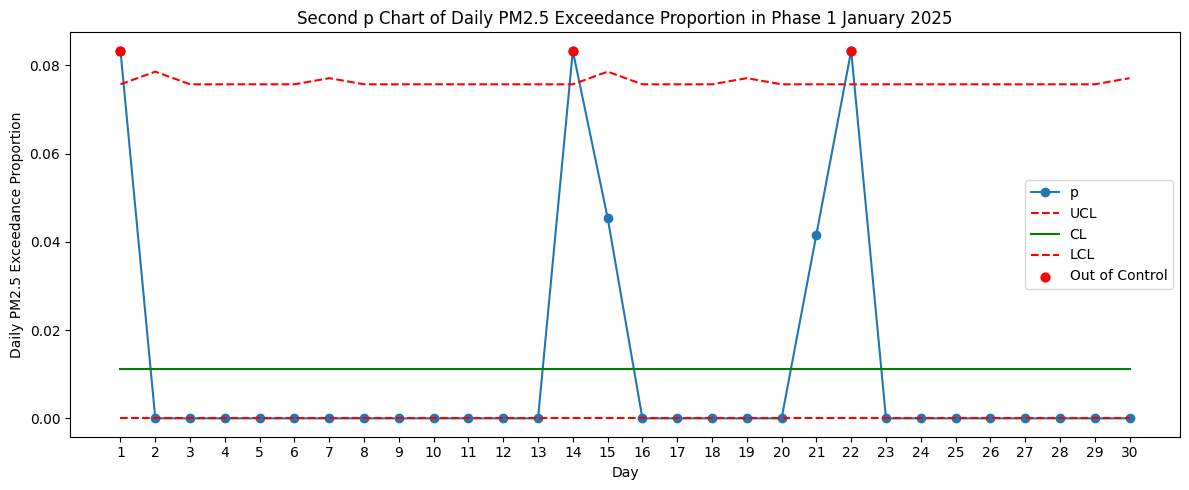

In [8]:
plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase1_clean) + 1)

plt.plot(
    x,
    phase1_clean["p"],
    marker="o",
    linestyle="-",
    label="p"
)

plt.plot(
    x,
    phase1_clean["p_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase1_clean["p_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase1_clean["p_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask = phase1_clean["out_of_control_p"]

plt.scatter(
    x[out_mask],
    phase1_clean.loc[out_mask, "p"],
    color="red",
    s=40,
    zorder=5,
    label="Out of Control"
)

plt.title("Second p Chart of Daily PM2.5 Exceedance Proportion in Phase 1 January 2025")
plt.xlabel("Day")
plt.ylabel("Daily PM2.5 Exceedance Proportion")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

## Phase 2

In [9]:
phase2_p = phase2_pchart_data.copy()
phase2_p = phase2_p.reset_index(drop=True)

# 使用 Phase 1 revised baseline，也就是排除 2025-01-22 後的 p_bar_clean
phase2_p = pchart_limits(phase2_p, p_bar_clean)


In [10]:
print("Phase 2 p chart points above UCL:")
print(
    phase2_p.loc[
        phase2_p["out_of_control_p_high"],
        ["date", "n", "exceed_count", "p", "p_lcl", "p_cl", "p_ucl"]
    ]
)

print(
    "Phase 2 p chart points above UCL count =",
    phase2_p["out_of_control_p_high"].sum()
)

Phase 2 p chart points above UCL:
          date   n  exceed_count         p  p_lcl     p_cl     p_ucl
5   2026-01-06  24             4  0.166667    0.0  0.01122  0.075721
15  2026-01-16  23             2  0.086957    0.0  0.01122  0.077108
Phase 2 p chart points above UCL count = 2


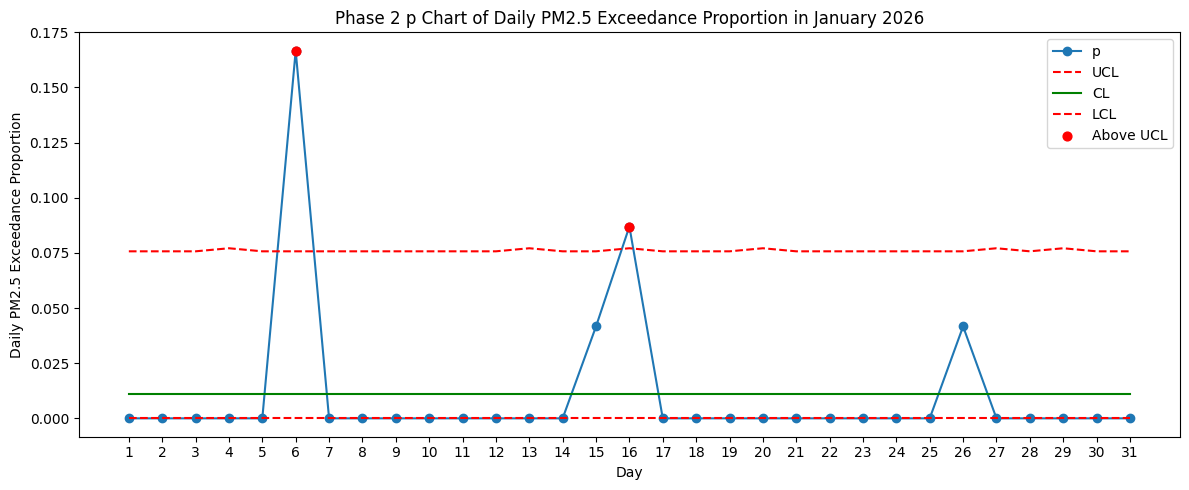

In [11]:
plt.figure(figsize=(12, 5))

x = np.arange(1, len(phase2_p) + 1)

plt.plot(
    x,
    phase2_p["p"],
    marker="o",
    linestyle="-",
    label="p"
)

plt.plot(
    x,
    phase2_p["p_ucl"],
    color="red",
    linestyle="--",
    label="UCL"
)

plt.plot(
    x,
    phase2_p["p_cl"],
    color="green",
    linestyle="-",
    label="CL"
)

plt.plot(
    x,
    phase2_p["p_lcl"],
    color="red",
    linestyle="--",
    label="LCL"
)

out_mask_phase2 = phase2_p["out_of_control_p_high"]

plt.scatter(
    x[out_mask_phase2],
    phase2_p.loc[out_mask_phase2, "p"],
    color="red",
    s=40,
    zorder=5,
    label="Above UCL"
)

plt.title("Phase 2 p Chart of Daily PM2.5 Exceedance Proportion in January 2026")
plt.xlabel("Day")
plt.ylabel("Daily PM2.5 Exceedance Proportion")
plt.xticks(x)
plt.legend()

plt.tight_layout()
plt.show()

## Summary

In [12]:
def print_pchart_limits(stats, chart_name):
    limit_table = stats[
        ["date", "n", "exceed_count", "p", "p_lcl", "p_cl", "p_ucl", "out_of_control_p_high"]
    ].copy()

    print(f"\n{chart_name} p chart limits:")
    print(limit_table)

    print(f"\n{chart_name} limits by subgroup size:")
    print(
        limit_table.groupby("n")[["p_lcl", "p_cl", "p_ucl"]]
        .first()
        .reset_index()
        .sort_values("n")
    )

    return limit_table

In [13]:
phase1_limits_table = print_pchart_limits(
    phase1_stats,
    "Initial Phase 1"
)

phase1_revised_limits_table = print_pchart_limits(
    phase1_clean,
    "Revised Phase 1"
)

phase2_limits_table = print_pchart_limits(
    phase2_p,
    "Phase 2"
)


Initial Phase 1 p chart limits:
          date   n  exceed_count         p  p_lcl      p_cl     p_ucl  \
0   2025-01-01  24             2  0.083333    0.0  0.020408  0.106993   
1   2025-01-02  22             0  0.000000    0.0  0.020408  0.110843   
2   2025-01-03  24             0  0.000000    0.0  0.020408  0.106993   
3   2025-01-04  24             0  0.000000    0.0  0.020408  0.106993   
4   2025-01-05  24             0  0.000000    0.0  0.020408  0.106993   
5   2025-01-06  24             0  0.000000    0.0  0.020408  0.106993   
6   2025-01-07  23             0  0.000000    0.0  0.020408  0.108855   
7   2025-01-08  24             0  0.000000    0.0  0.020408  0.106993   
8   2025-01-09  24             0  0.000000    0.0  0.020408  0.106993   
9   2025-01-10  24             0  0.000000    0.0  0.020408  0.106993   
10  2025-01-11  24             0  0.000000    0.0  0.020408  0.106993   
11  2025-01-12  24             0  0.000000    0.0  0.020408  0.106993   
12  2025-01-13  24